In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
healthy_data = pd.read_csv("../data/processed/02_healthy_data.csv")

healthy_data

,sample.ID,BioProject,Age,Gender,BMI,Geography,Sequencer,MgsRichness,GeneRichness,enteroType,...,msp_2176,msp_2178,msp_2180,msp_2191,msp_2195,msp_2196,msp_2207,msp_2209,msp_2210,msp_2211
0,ERS608499,PRJEB7774,68.0,Male,32.0,Austria,Illumina HiSeq 2000,265,686859,ET-Firmicutes,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ERS608489,PRJEB7774,60.0,Female,22.0,Austria,Illumina HiSeq 2000,228,616715,ET-Firmicutes,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ERS608521,PRJEB7774,68.0,Male,23.0,Austria,Illumina HiSeq 2000,254,627031,ET-Firmicutes,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ERS608508,PRJEB7774,66.0,Male,30.0,Austria,Illumina HiSeq 2000,135,328130,ET-Bacteroides,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ERS608511,PRJEB7774,73.0,Male,29.0,Austria,Illumina HiSeq 2000,142,388101,ET-Bacteroides,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3287,SRS149244,PRJNA48479,NaN,Male,NaN,USA,Illumina HiSeq 2000,91,276928,ET-Bacteroides,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3288,SRS149325,PRJNA48479,NaN,Female,NaN,USA,Illumina HiSeq 2000,201,543906,ET-Bacteroides,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3289,SRS149784,PRJNA48479,NaN,Female,NaN,USA,Illumina HiSeq 2000,283,671285,ET-Firmicutes,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3290,SRS149879,PRJNA48479,NaN,Female,NaN,USA,Illumina HiSeq 2000,161,502900,ET-Firmicutes,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Look at how many different studies are involved here:

In [ ]:
print(healthy_data["BioProject"].nunique())


grouped_by_country = healthy_data.groupby("Geography")

grouped_by_country["BioProject"].nunique()


grouped_by_project = healthy_data.groupby(["BioProject","Geography"])

grouped_by_project.size()


35


BioProject   Geography 
PRJDB4176    Japan         291
PRJEB10878   China          54
PRJEB12449   USA            52
PRJEB15371   China          55
PRJEB17784   Germany        28
PRJEB1786    Sweden         43
PRJEB18755   China          36
PRJEB2054    Spain          14
PRJEB20800   Denmark        57
PRJEB21528   China         122
PRJEB27928   Germany        60
PRJEB28687   Thailand       15
             USA            40
PRJEB38483   UK             48
PRJEB4336    Denmark       278
PRJEB6070    France         61
             Germany         5
PRJEB6337    China         114
PRJEB6997    China          97
PRJEB7774    Austria        63
PRJEB9584    UK            211
PRJNA177201  Sweden         15
PRJNA217052  Fiji          193
PRJNA268964  Peru           36
             USA            22
PRJNA278393  Italy          11
             Tanzania       27
PRJNA289586  Luxembourg     52
PRJNA327106  USA            37
PRJNA328899  Mongolia      110
PRJNA356225  China          15
PRJNA379741  US

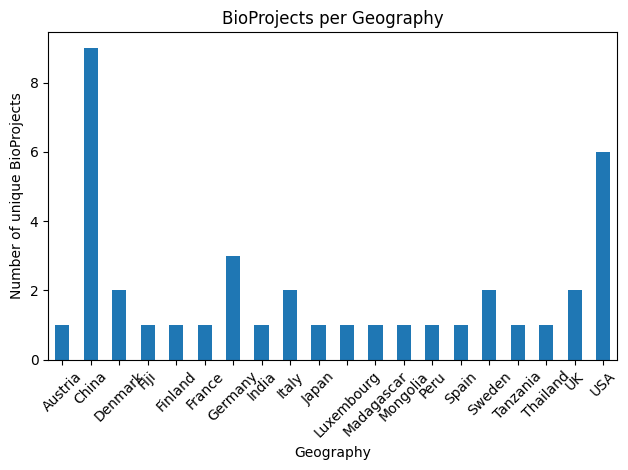

In [10]:
count_study = healthy_data.groupby("Geography")["BioProject"].nunique()


count_study.plot(kind="bar")
plt.ylabel("Number of unique BioProjects")
plt.title("BioProjects per Geography")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

There are overall 35 different study cohorts

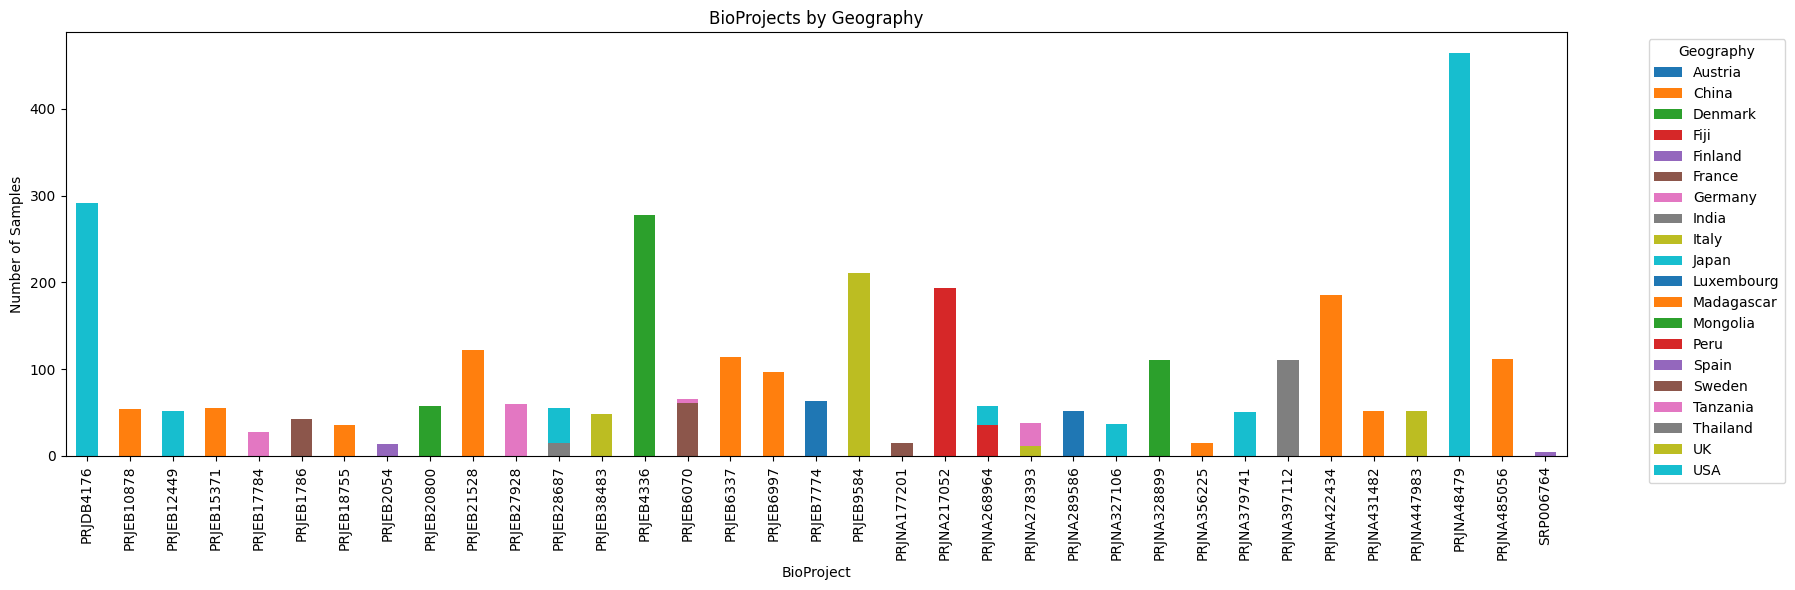

In [30]:
pivot = healthy_data.groupby(["BioProject", "Geography"]).size().unstack(fill_value=0)

pivot.plot(kind="bar", stacked=True, figsize=(18, 6))
plt.ylabel("Number of Samples")
plt.title("BioProjects by Geography")
plt.xticks(rotation=90)
plt.legend(title="Geography", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()